In [76]:
# This is an analysis of the mortgage dataset from kaggle
# https://www.kaggle.com/datasets/datawitharyan/financial-loan-dataset?resource=download

In [1]:
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel(f"financial_loan.xlsx")

## Generalities of the dataset

In [ ]:
df

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,next_payment_date,member_id,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,Charged Off,2021-05-13,1314167,car,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,Fully Paid,2021-02-15,1288686,car,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,Charged Off,2021-02-09,1304116,car,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,Fully Paid,2021-04-12,1272024,car,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,Fully Paid,2021-02-15,1302971,car,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,Current,2021-06-16,992381,wedding,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,Current,2021-06-16,1192039,wedding,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,Current,2021-06-16,1089898,wedding,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,Current,2021-06-16,1194971,wedding,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [ ]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

In [ ]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


# Small data cleanup

## Assign right datatypes to the features

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [ ]:
# Deal with categorical data

cat_cols = [
    'address_state',
    'application_type',
    'grade',
    'loan_status',
    'purpose',
    'sub_grade',
    'term',
    'verification_status',
    'home_ownership'
]

df[cat_cols] = df[cat_cols].astype('category').copy()

In [ ]:
df.term.unique()

[' 60 months', ' 36 months']
Categories (2, object): [' 36 months', ' 60 months']

In [ ]:
# Deal with employment length 

def clean_emp_length(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = x.strip()
    if x == '< 1 year':
        return 0
    if x == '10+ years':
        return 10
    return int(x.split()[0])

df['emp_length'] = df['emp_length'].apply(clean_emp_length).copy()





In [ ]:
# Deal with mortgage grade 

grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
df['grade'] = pd.Categorical(df['grade'], categories=grade_order, ordered=True)




sub_grade_order = list(df['sub_grade'].unique().sort_values())
df['sub_grade'] = pd.Categorical(df['sub_grade'], categories=sub_grade_order, ordered=True)


In [ ]:
# Deal with datetime 
date_cols = [
    "issue_date",
    "last_credit_pull_date",
    "last_payment_date",
    "next_payment_date",
]

df[date_cols] = df[date_cols].apply(pd.to_datetime)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  category      
 2   application_type       38576 non-null  category      
 3   emp_length             38576 non-null  int64         
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  category      
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  category      
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

## Find missing values

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64


Text(0, 0.5, 'Count of Missing Values')

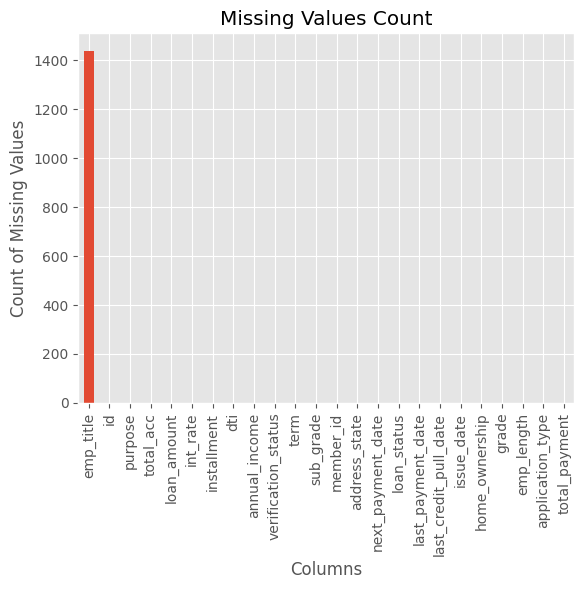

In [ ]:
## Check for missing values
print(df.isna().sum())
ax = df.isna().sum().sort_values(ascending=False).plot(kind='bar')

ax.set_title('Missing Values Count')
ax.set_xlabel('Columns')
ax.set_ylabel('Count of Missing Values')

## Look for duplicates

In [ ]:
## Check for duplicates
print(f"Number of fully duplicate rows: {df.duplicated().sum()}")

print("Shows the second occurrence of duplicate rows based on the 'emp_title' column:")
df.loc[df.duplicated(subset = ['emp_title'], keep = 'last')]

Number of fully duplicate rows: 0
Shows the second occurrence of duplicate rows based on the 'emp_title' column:


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,next_payment_date,member_id,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
6,1067441,TX,INDIVIDUAL,10,American Airlines,C,MORTGAGE,2021-11-19,2021-06-14,2021-12-13,Fully Paid,2022-01-13,1301833,car,C2,36 months,Verified,94800.0,0.2453,205.86,0.1427,6000,30,7218
10,1057766,TX,INDIVIDUAL,10,Ericsson,B,MORTGAGE,2021-07-22,2021-09-13,2021-08-13,Fully Paid,2021-09-13,1289131,car,B5,36 months,Not Verified,75000.0,0.0880,181.15,0.1269,5400,33,6277
15,1060995,RI,INDIVIDUAL,0,HSA-UWC,B,RENT,2021-12-11,2021-02-14,2021-10-13,Charged Off,2021-11-13,1292578,car,B4,36 months,Source Verified,60000.0,0.0630,400.99,0.1242,12000,14,9547
19,1058060,MD,INDIVIDUAL,10,NaN,D,OWN,2021-02-02,2021-05-16,2021-02-15,Fully Paid,2021-03-15,1289636,car,D1,36 months,Not Verified,40000.0,0.0957,176.51,0.1629,5000,13,6361
21,207910,FL,INDIVIDUAL,0,NaN,A,MORTGAGE,2021-01-08,2021-05-16,2021-02-10,Charged Off,2021-03-10,183496,car,A2,36 months,Not Verified,120000.0,0.0767,69.14,0.0743,2225,20,2508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38326,781758,CA,INDIVIDUAL,5,NaN,C,RENT,2021-06-11,2021-04-16,2021-06-14,Fully Paid,2021-07-14,984673,wedding,C4,36 months,Verified,60000.0,0.2024,104.91,0.1562,3000,23,3777
38357,788049,NJ,INDIVIDUAL,5,AT&T,D,RENT,2021-06-11,2021-07-12,2021-07-12,Fully Paid,2021-08-12,991678,wedding,D3,36 months,Verified,32000.0,0.1819,70.80,0.1649,2000,12,2309
38371,1017940,CA,INDIVIDUAL,10,California Department of Corrections,C,MORTGAGE,2021-11-11,2021-03-15,2021-02-15,Fully Paid,2021-03-15,1246375,wedding,C1,60 months,Not Verified,63919.2,0.0843,276.06,0.1349,12000,16,15922
38395,738177,NC,INDIVIDUAL,8,Travelers,D,MORTGAGE,2021-04-11,2021-03-14,2021-03-14,Fully Paid,2021-04-14,935505,wedding,D3,60 months,Not Verified,74500.0,0.1311,95.75,0.1528,4000,16,5363


# Feature Exploration

## Feature understanding and visualization

In [ ]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

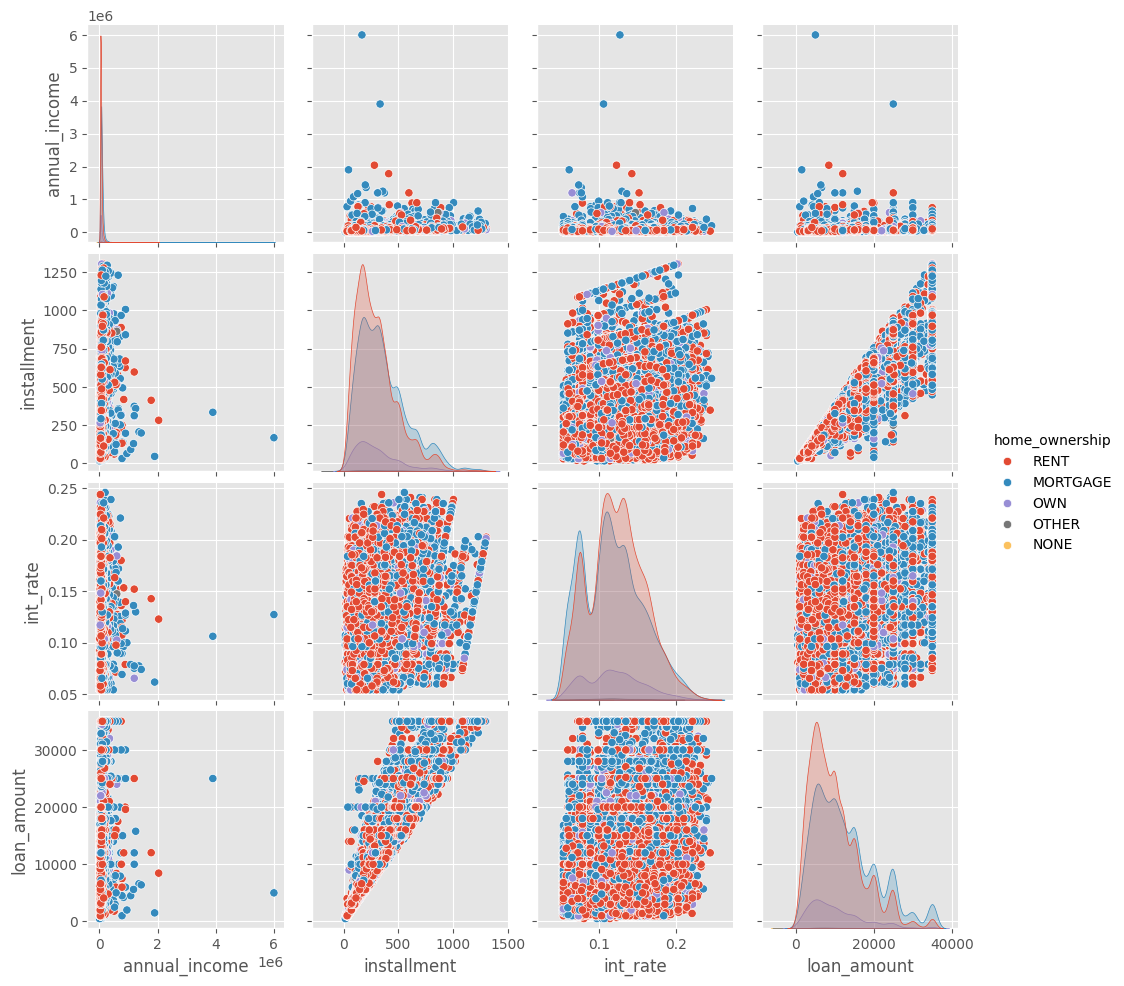

In [ ]:
sns.pairplot(df,
             vars=['annual_income',
                   'installment','int_rate','loan_amount'],
            hue='home_ownership')
plt.show()

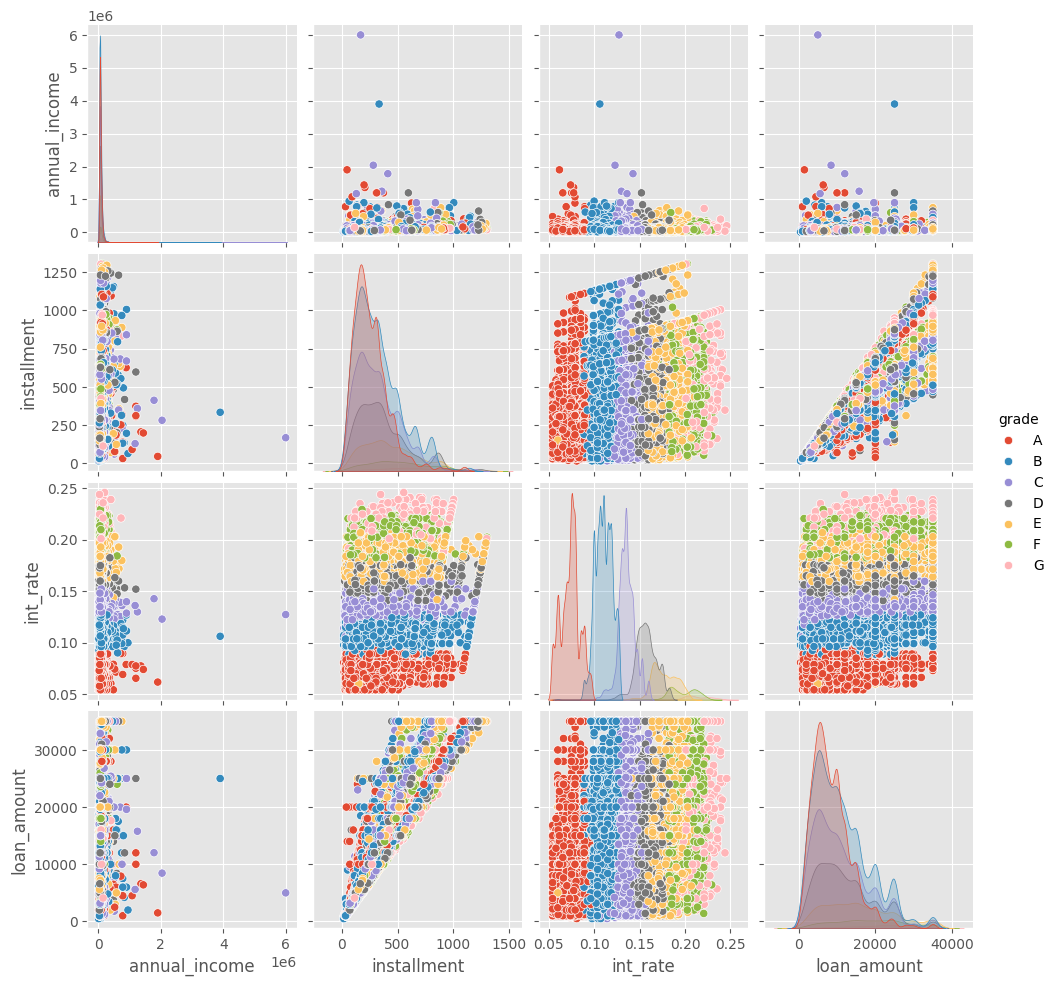

In [ ]:
sns.pairplot(df,
             vars=['annual_income',
                   'installment','int_rate','loan_amount'],
            hue='grade')
plt.show()

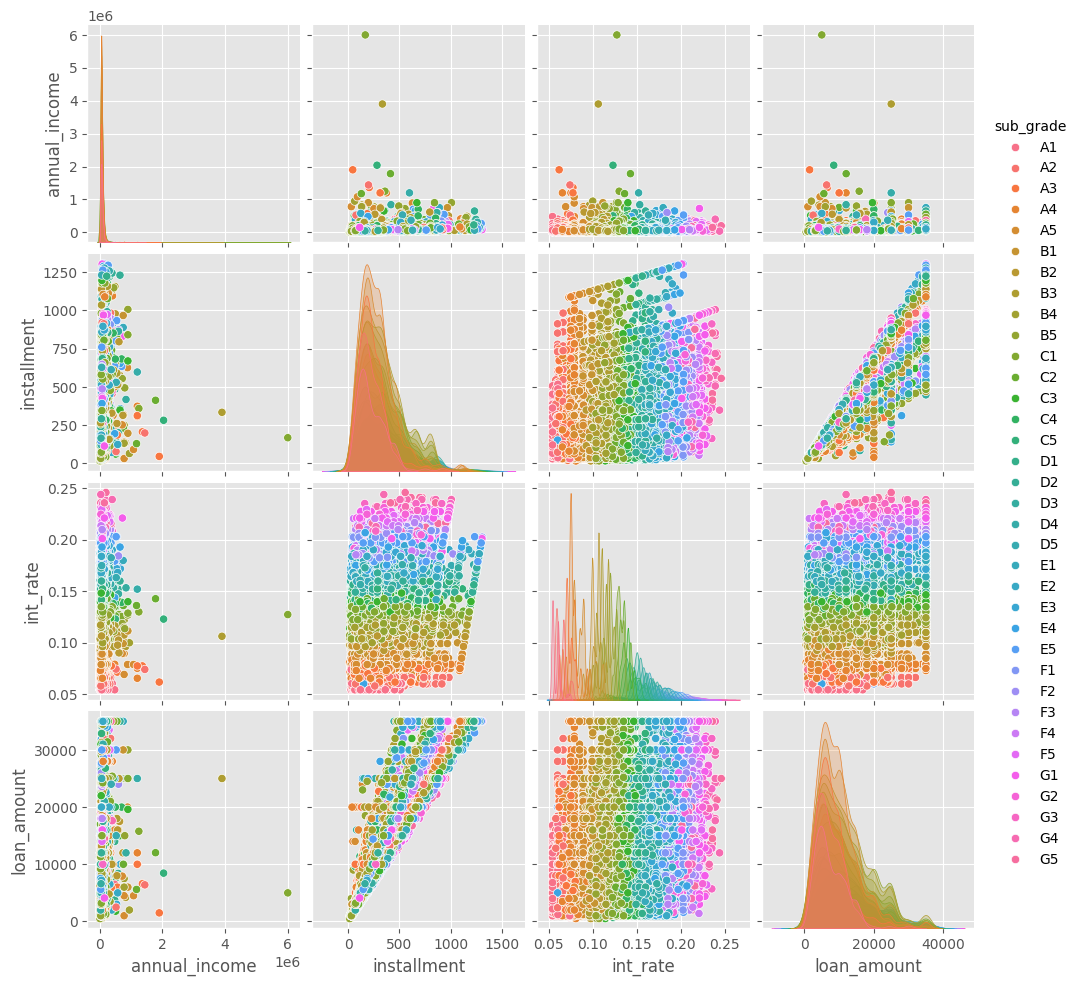

In [ ]:
sns.pairplot(df,
             vars=['annual_income',
                   'installment','int_rate','loan_amount'],
            hue='sub_grade')
plt.show()

Text(0, 0.5, 'Count')

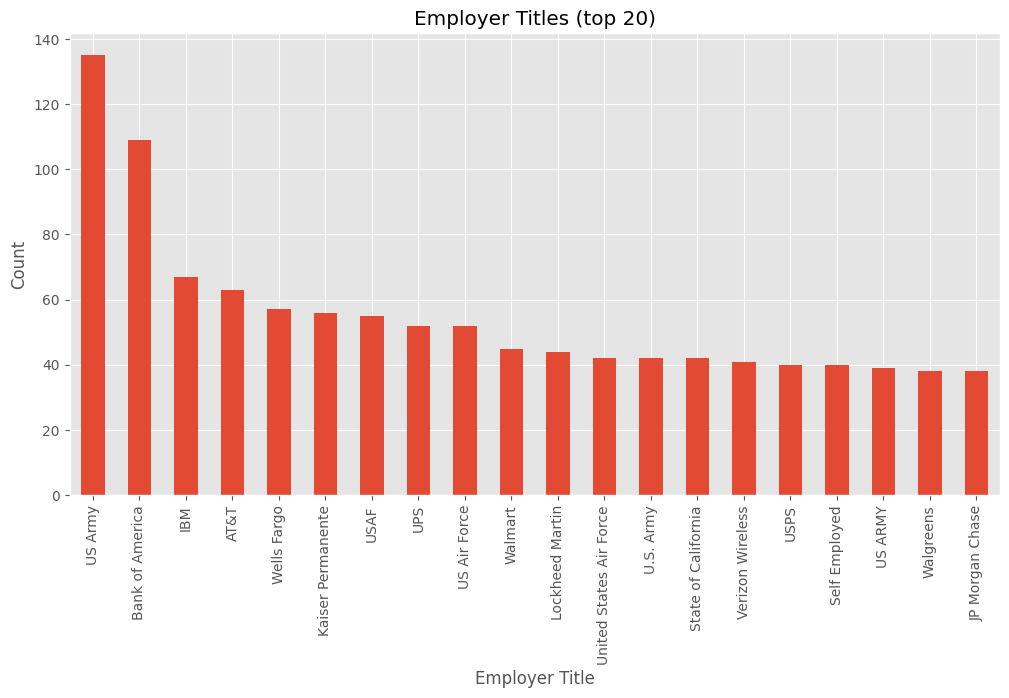

In [ ]:
ax = df.groupby('emp_title').size().sort_values(ascending=False).head(20).plot(kind='bar', figsize=(12, 6))
ax.set_title('Employer Titles (top 20)')
ax.set_xlabel('Employer Title')
ax.set_ylabel('Count')

Text(0, 0.5, 'Count')

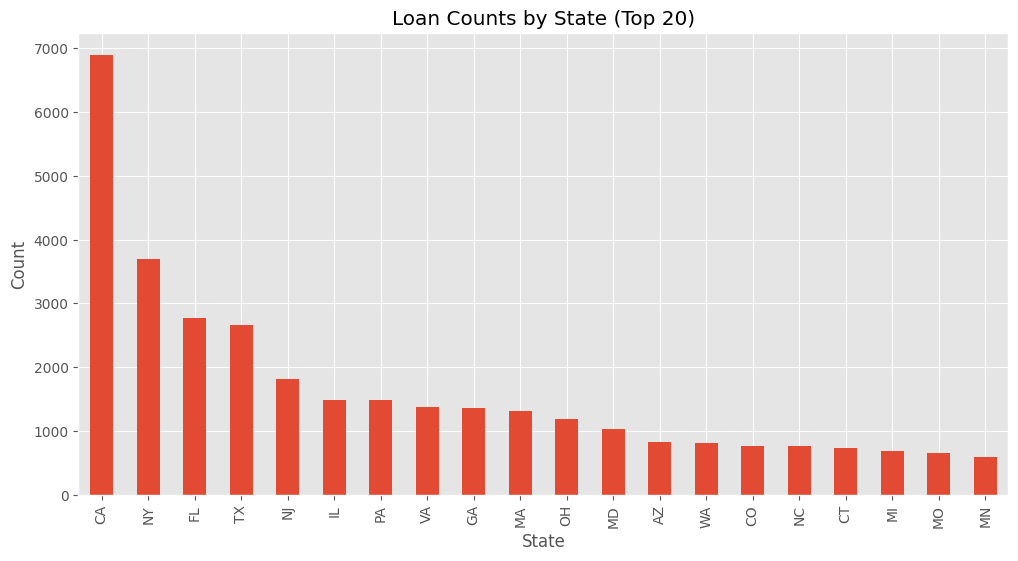

In [ ]:
df.groupby('address_state').size().sort_values(ascending=False).head(20).plot(kind='bar', figsize=(12, 6))
plt.title('Loan Counts by State (Top 20)')
plt.xlabel('State')
plt.ylabel('Count')

<Axes: xlabel='grade'>

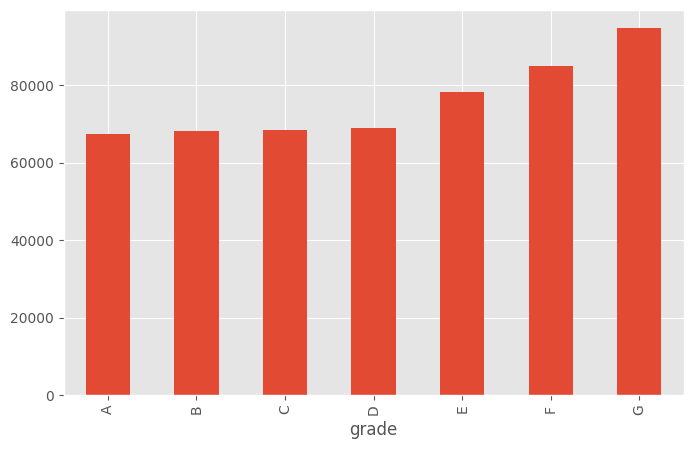

In [ ]:
df.groupby('grade')["annual_income"].mean().plot(kind='bar', figsize=(8, 5))

/tmp/ipykernel_67783/953955367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='grade', y='annual_income', data=df[df['annual_income'] < 200000],


<Axes: xlabel='grade', ylabel='annual_income'>

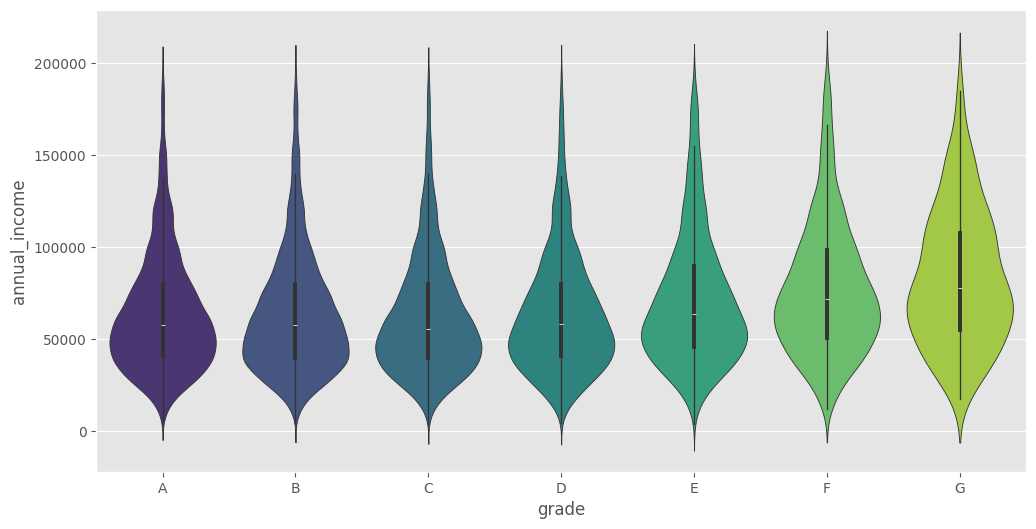

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='grade', y='annual_income', data=df[df['annual_income'] < 200000], 
               order=['A','B','C','D','E','F','G'], palette='viridis')

<Axes: xlabel='purpose'>

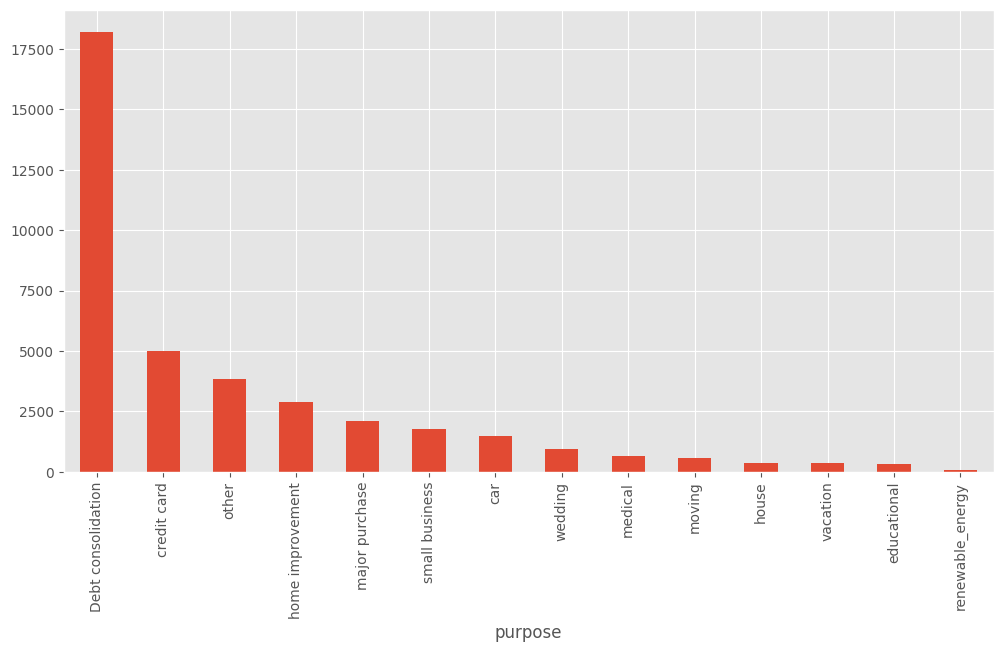

In [ ]:
df.purpose.value_counts().plot(kind='bar', figsize=(12, 6))

Text(0.5, 0, 'Loan Amount')

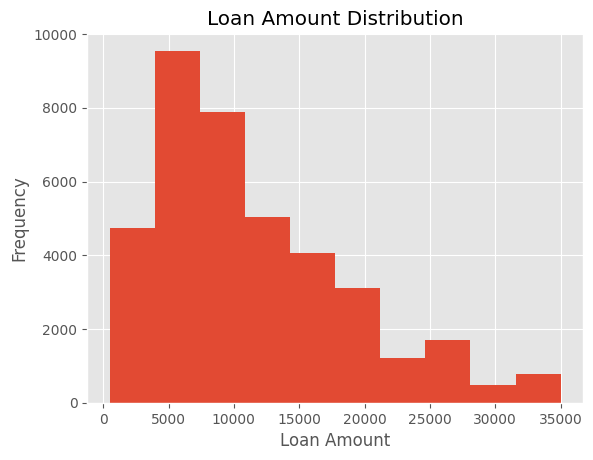

In [ ]:
ax = df['loan_amount'].plot(kind='hist',
                          title='Loan Amount Distribution')
ax.set_xlabel('Loan Amount')

In [ ]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

# Practice questions

- What state has the largest loans?

Text(0.5, 0, 'State')

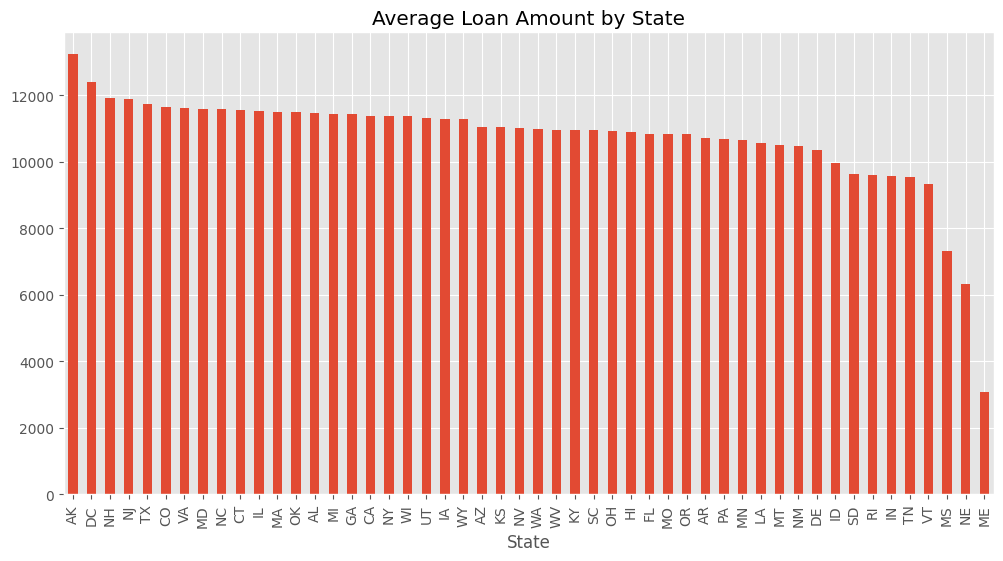

In [ ]:
ax = df.groupby("address_state")["loan_amount"].mean().sort_values(ascending=False).plot(kind="bar",figsize=(12,6))


ax.set_title("Average Loan Amount by State")
ax.set_xlabel("State")

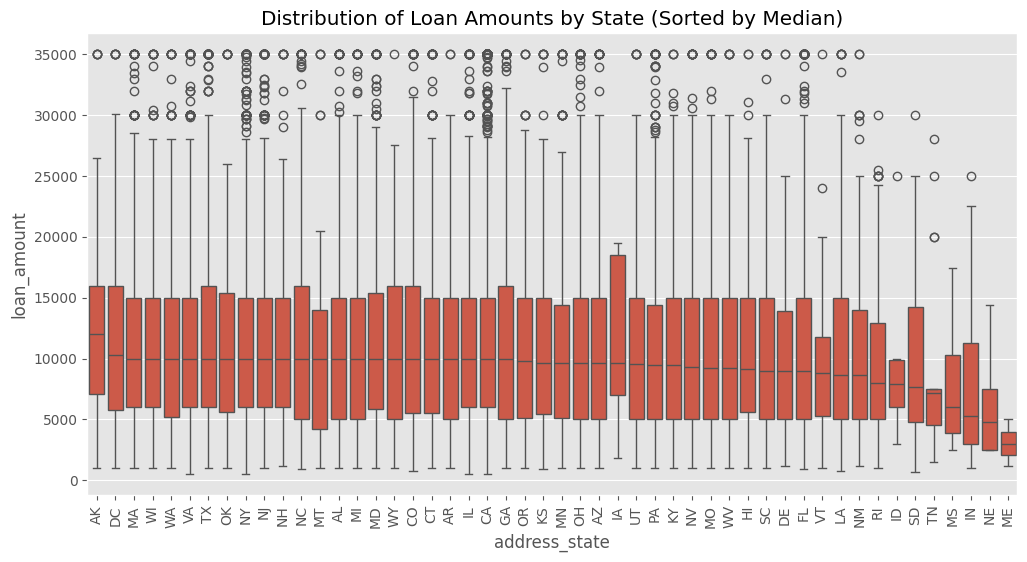

In [ ]:
fig,ax = plt.subplots(figsize=(12,6))

state_order = df.groupby("address_state")["loan_amount"].median().sort_values(ascending=False).index

sns.boxplot(x=df["address_state"], y=df["loan_amount"],ax=ax, order=state_order)

plt.xticks(rotation=90)
ax.set_title("Distribution of Loan Amounts by State (Sorted by Median)")
plt.show()

- Question: Make a model to predict the (sub-)grade of the mortgage

# Feature engineering

## Feature selection
Goal is to find the relevant features and which ones we can drop

28526


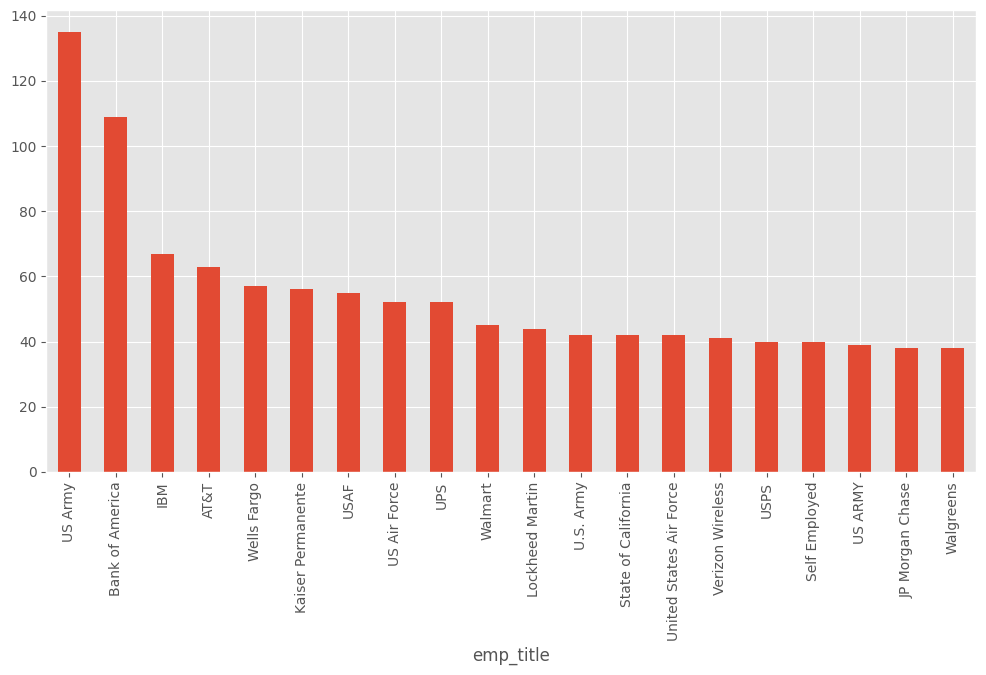

In [ ]:
df['emp_title'].value_counts().head(20).plot(kind='bar', figsize=(12, 6))
print(len(df['emp_title'].unique()))

In [ ]:
rdf = df.drop(columns=['id','member_id','issue_date','last_credit_pull_date',
                       'next_payment_date', 'last_payment_date',
                       'application_type','grade',"emp_title"]).copy()

rdf

,address_state,emp_length,home_ownership,loan_status,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,GA,0,RENT,Charged Off,car,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,CA,9,RENT,Fully Paid,car,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,CA,4,RENT,Charged Off,car,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,TX,0,MORTGAGE,Fully Paid,car,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,IL,10,MORTGAGE,Fully Paid,car,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,NJ,0,MORTGAGE,Current,wedding,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,NY,8,RENT,Current,wedding,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,CA,5,RENT,Current,wedding,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,NY,5,RENT,Current,wedding,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


# Predictive Modeling

## Make the train test split

In [ ]:
columns = [c for c in rdf.columns if c not in ['sub_grade']]

X = rdf[columns]
y = rdf['sub_grade']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

X_train

,address_state,emp_length,home_ownership,loan_status,purpose,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
7542,WA,6,RENT,Charged Off,Debt consolidation,36 months,Not Verified,41000.0,0.0834,172.82,0.1479,5000,12,1279
30069,NJ,6,RENT,Charged Off,major purchase,60 months,Source Verified,30000.0,0.1684,230.67,0.1361,10000,16,7254
28709,NJ,10,OWN,Fully Paid,major purchase,36 months,Not Verified,57600.0,0.1190,202.17,0.0749,6500,25,7000
4453,NY,1,RENT,Fully Paid,credit card,36 months,Source Verified,14400.0,0.1883,63.62,0.1349,1875,23,2302
12655,NY,4,RENT,Fully Paid,Debt consolidation,36 months,Not Verified,100000.0,0.2466,495.29,0.1645,14000,17,17848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,CA,4,RENT,Fully Paid,credit card,36 months,Source Verified,23000.0,0.0736,142.54,0.1186,4300,18,4829
36107,AZ,1,MORTGAGE,Fully Paid,small business,36 months,Not Verified,23000.0,0.0214,77.03,0.0963,2400,23,2773
5910,TX,6,RENT,Fully Paid,credit card,60 months,Source Verified,90000.0,0.0272,168.64,0.1557,7000,15,10016
19268,NY,10,RENT,Fully Paid,Debt consolidation,36 months,Verified,126000.0,0.1714,860.91,0.1670,24250,31,28923


## LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the LightGBM Classifier
# 'multi_logloss' is used for multiclass; 'binary_logloss' for two classes
model = lgb.LGBMClassifier(
    objective='multiclass', # Use 'binary' if you only have two categories
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=100,
    random_state=42,
    lambda_l1=1.5,  # Higher values increase sparsity
    lambda_l2=1.0,
)

# 2. Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=10)],
    
)

# 3. Make predictions
y_pred = model.predict(X_test)



[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.5
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000910 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1654
[LightGBM] [Info] Number of data points in the train set: 30860, number of used features: 14
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.5
[LightGBM] [Info] Start tr

--- Model Performance ---
Accuracy: 0.9173

Classification Report:
              precision    recall  f1-score   support

          A1       0.97      0.93      0.95       210
          A2       0.98      0.99      0.98       288
          A3       0.91      0.86      0.89       348
          A4       0.93      0.96      0.94       561
          A5       0.94      0.98      0.96       531
          B1       0.82      0.85      0.83       350
          B2       0.94      0.97      0.96       398
          B3       0.93      0.96      0.95       567
          B4       0.93      0.87      0.90       491
          B5       0.96      0.98      0.97       529
          C1       0.87      0.84      0.85       418
          C2       0.87      0.88      0.87       394
          C3       0.93      0.97      0.95       298
          C4       0.95      0.96      0.95       240
          C5       0.91      0.97      0.94       230
          D1       0.98      0.93      0.96       183
          D2  

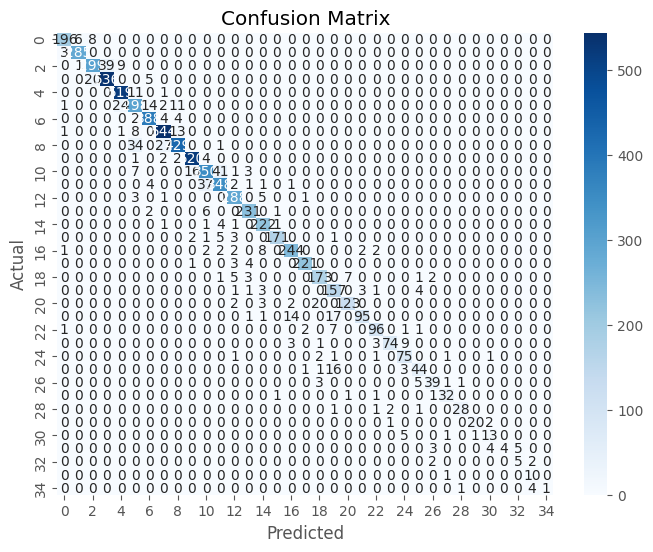

In [ ]:
# 4. Evaluation
print("--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

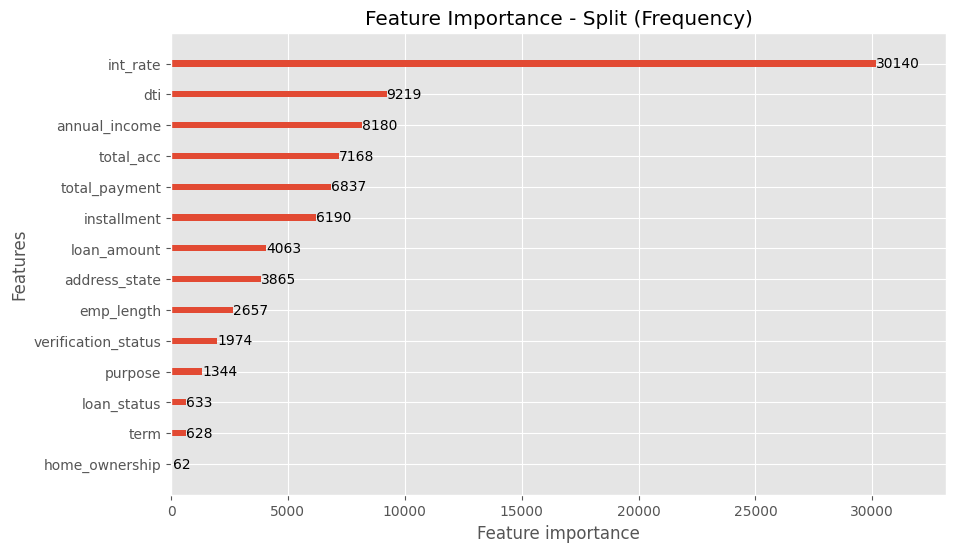

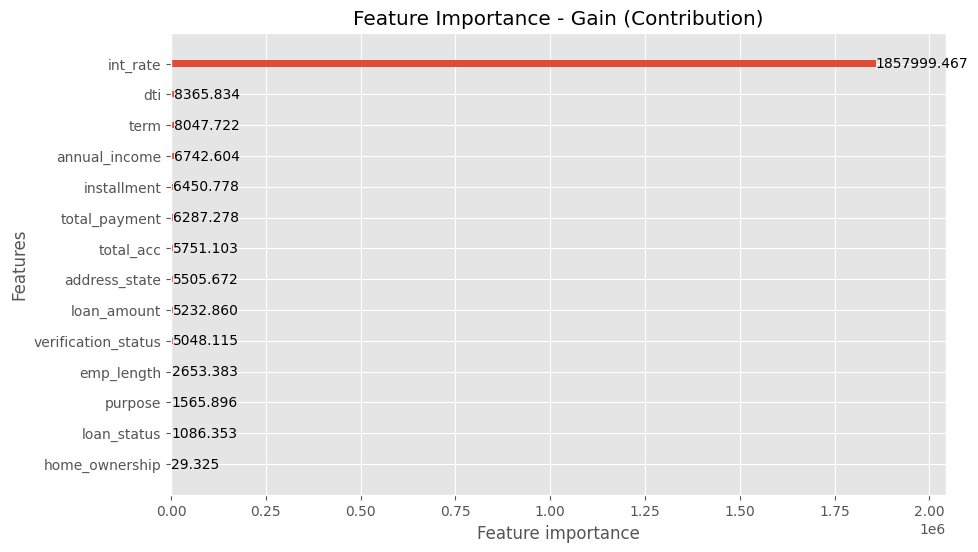

In [ ]:
# 1. Importance by 'split' (Frequency)
# This shows how many times a feature was used to make a decision
lgb.plot_importance(model, importance_type='split', max_num_features=20, figsize=(10, 6))
plt.title("Feature Importance - Split (Frequency)")
plt.show()

# 2. Importance by 'gain' (Total Information Gain)
# This shows which features actually contributed the most to the model's accuracy
lgb.plot_importance(model, importance_type='gain', max_num_features=20, figsize=(10, 6))
plt.title("Feature Importance - Gain (Contribution)")
plt.show()

## LightGBM with cross validation

In [81]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Initialize the base model
lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    random_state=42,
    verbosity=-1 # Silences unnecessary warnings during search
)

# 2. Define the parameter grid
# We provide ranges for the model to "explore"
param_dist = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40, 60],
    'max_depth': [-1, 10, 20], # -1 means no limit
    'lambda_l1': [0, 1, 5],
    'lambda_l2': [0, 1, 5],
    'min_child_samples': [10, 20, 30]
}

# 3. Set up Randomized Search
# cv=5 means 5-fold cross-validation
# n_iter=10 means it will try 10 random combinations
rdm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=1, 
    scoring='accuracy',
    cv=5, 
    verbose=3,
    n_jobs=-1
)

# 4. Fit the search (This handles X_train/y_train splitting internally)
rdm_search.fit(X_train, y_train)

# 5. Get the best model
best_model = rdm_search.best_estimator_

print(f"Best Parameters: {rdm_search.best_params_}")
print(f"Best CV Score: {rdm_search.best_score_:.4f}")

# 6. Evaluate on the actual test set
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 2/5] END lambda_l1=1, lambda_l2=5, learning_rate=0.01, max_depth=10, min_child_samples=30, n_estimators=100, num_leaves=31;, score=0.914 total time=46.2min
[CV 5/5] END lambda_l1=1, lambda_l2=5, learning_rate=0.01, max_depth=10, min_child_samples=30, n_estimators=100, num_leaves=31;, score=0.908 total time=47.3min
[CV 3/5] END lambda_l1=1, lambda_l2=5, learning_rate=0.01, max_depth=10, min_child_samples=30, n_estimators=100, num_leaves=31;, score=0.911 total time=47.3min
[CV 4/5] END lambda_l1=1, lambda_l2=5, learning_rate=0.01, max_depth=10, min_child_samples=30, n_estimators=100, num_leaves=31;, score=0.913 total time=47.3min
[CV 1/5] END lambda_l1=1, lambda_l2=5, learning_rate=0.01, max_depth=10, min_child_samples=30, n_estimators=100, num_leaves=31;, score=0.917 total time=47.3min
Best Parameters: {'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 30, 'max_depth': 10, 'learning_rate': 0.01, 'lambda_l2': 5, 'la

/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

--- Model Performance ---
Accuracy: 0.9076

Classification Report:
              precision    recall  f1-score   support

          A1       0.98      0.93      0.95       210
          A2       0.97      1.00      0.98       288
          A3       0.96      0.79      0.87       348
          A4       0.90      0.98      0.94       561
          A5       0.91      0.98      0.94       531
          B1       0.79      0.82      0.80       350
          B2       0.94      0.98      0.96       398
          B3       0.89      0.98      0.93       567
          B4       0.98      0.82      0.89       491
          B5       0.93      0.99      0.96       529
          C1       0.85      0.83      0.84       418
          C2       0.89      0.85      0.87       394
          C3       0.92      0.95      0.94       298
          C4       0.95      0.96      0.96       240
          C5       0.92      0.97      0.94       230
          D1       0.98      0.93      0.96       183
          D2  

/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

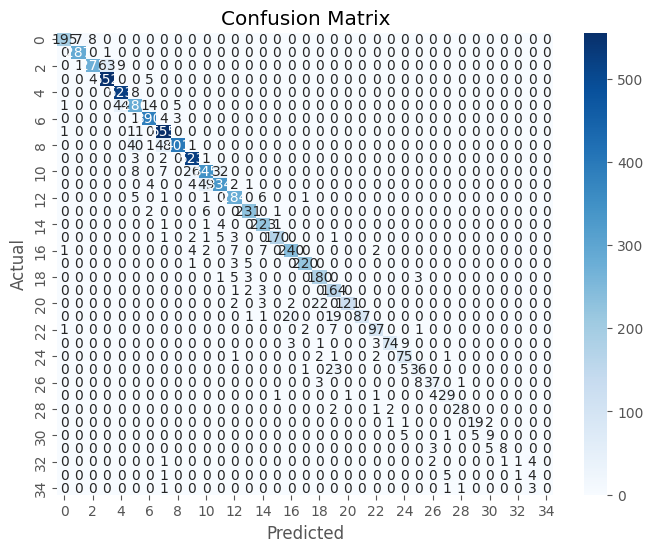

In [82]:
# 4. Evaluation
print("--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

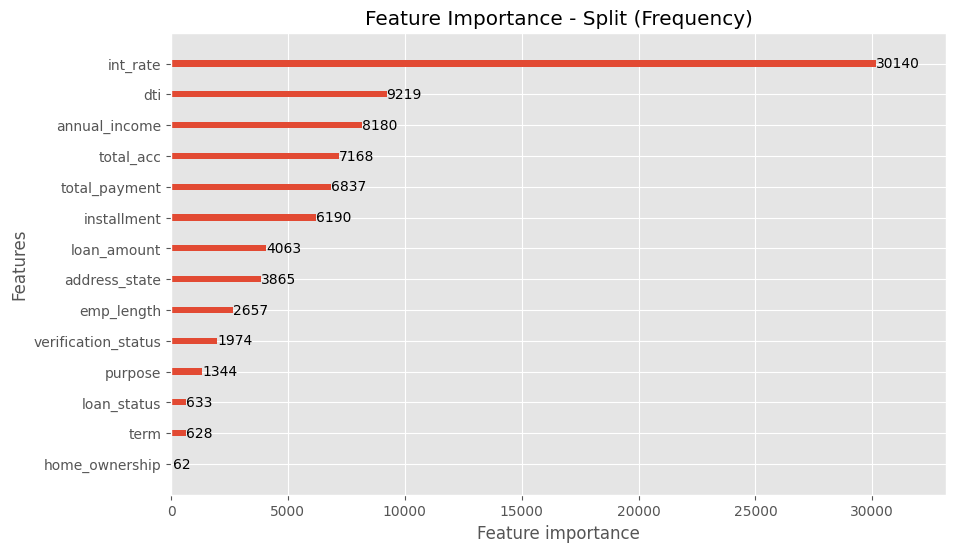

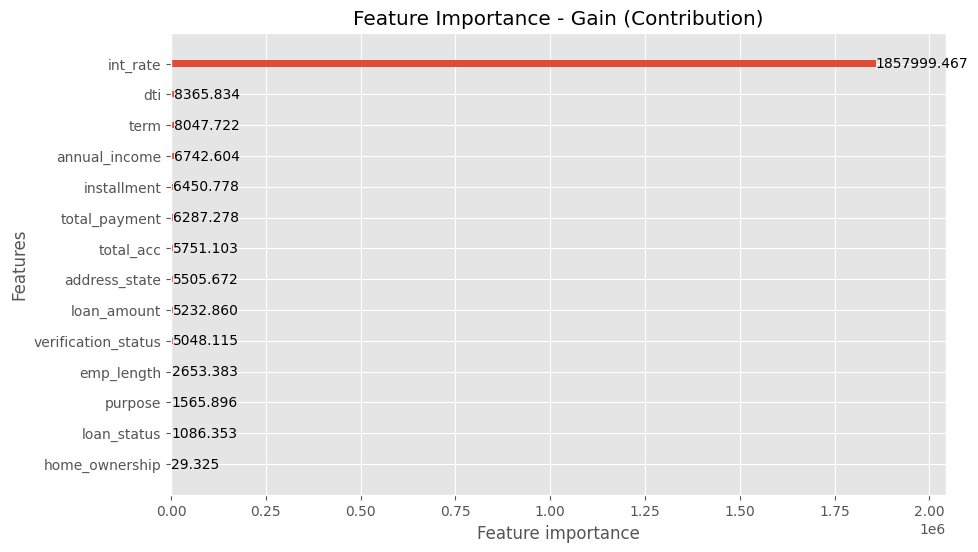

In [83]:
# 1. Importance by 'split' (Frequency)
# This shows how many times a feature was used to make a decision
lgb.plot_importance(model, importance_type='split', max_num_features=20, figsize=(10, 6))
plt.title("Feature Importance - Split (Frequency)")
plt.show()

# 2. Importance by 'gain' (Total Information Gain)
# This shows which features actually contributed the most to the model's accuracy
lgb.plot_importance(model, importance_type='gain', max_num_features=20, figsize=(10, 6))
plt.title("Feature Importance - Gain (Contribution)")
plt.show()

## Logistic Regressio, Lasso

I need to first encode the categorical features because they dont work well with logistic regressionm

In [ ]:
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numeric Features:", numeric_features)

Categorical Features: ['address_state', 'home_ownership', 'loan_status', 'purpose', 'term', 'verification_status']
Numeric Features: ['emp_length', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 2. Create the preprocessing bundles
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

# 3. Create the final pipeline
# We use drop='first' in OneHotEncoder to avoid the "dummy variable trap"
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', C=1.0))
])

# 4. Fit the whole thing
lasso_pipeline.fit(X_train, y_train)

# 5. Predict and evaluate
y_pred = lasso_pipeline.predict(X_test)

--- Model Performance ---
Accuracy: 0.2054

Classification Report:
              precision    recall  f1-score   support

          A1       0.61      0.62      0.62       210
          A2       0.61      0.20      0.31       288
          A3       0.23      0.07      0.11       348
          A4       0.35      0.73      0.48       561
          A5       0.37      0.32      0.34       531
          B1       0.22      0.04      0.07       350
          B2       0.18      0.02      0.04       398
          B3       0.19      0.51      0.28       567
          B4       0.15      0.14      0.14       491
          B5       0.14      0.34      0.20       529
          C1       0.12      0.12      0.12       418
          C2       0.09      0.11      0.10       394
          C3       0.14      0.04      0.06       298
          C4       0.11      0.05      0.07       240
          C5       0.13      0.04      0.06       230
          D1       0.10      0.32      0.15       183
          D2  

/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

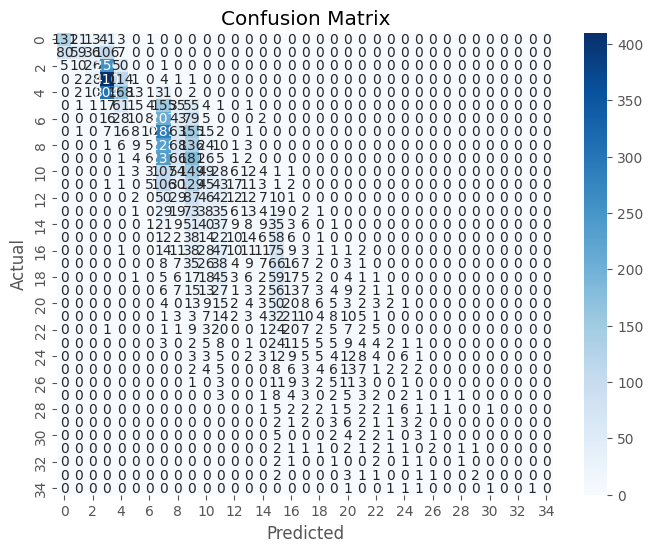

In [ ]:
# 4. Evaluation
print("--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Random Forest

In [ ]:
categorical_features

['address_state',
 'home_ownership',
 'loan_status',
 'purpose',
 'term',
 'verification_status']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Identify your categorical and numeric columns automatically
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

# 2. Create the preprocessor
# Note: Random Forest doesn't technically require scaling, but it doesn't hurt.
# However, it MUST have numeric inputs.

dropping = True
if dropping == True:
    preprocessor = ColumnTransformer(
        transformers=[
            ('drop_cols', 'drop', categorical_features), # This explicitly drops these columns
            # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ], remainder='passthrough') # 'passthrough' keeps numeric columns as they are
if dropping == False:
    preprocessor = ColumnTransformer(
        transformers=[
            # ('drop_cols', 'drop', categorical_features), # This explicitly drops these columns
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ], remainder='passthrough') # 'passthrough' keeps numeric columns as they are

# 3. Define the Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=None,        # How deep each tree can go
    min_samples_split=2,   # Minimum samples to split a node
    random_state=42,
    n_jobs=-1              # Use all CPU cores for faster training
)

# 4. Create and fit the Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

rf_pipeline.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred_rf = rf_pipeline.predict(X_test)

print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Performance ---
Accuracy: 0.6821
              precision    recall  f1-score   support

          A1       0.95      0.92      0.93       210
          A2       0.91      0.91      0.91       288
          A3       0.90      0.68      0.78       348
          A4       0.79      0.86      0.82       561
          A5       0.79      0.93      0.85       531
          B1       0.77      0.65      0.70       350
          B2       0.69      0.75      0.72       398
          B3       0.66      0.85      0.74       567
          B4       0.80      0.67      0.73       491
          B5       0.74      0.77      0.76       529
          C1       0.63      0.68      0.66       418
          C2       0.67      0.69      0.68       394
          C3       0.67      0.56      0.61       298
          C4       0.74      0.52      0.61       240
          C5       0.65      0.60      0.62       230
          D1       0.58      0.60      0.59       183
          D2       0.57      0

/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

--- Model Performance ---
Accuracy: 0.2054

Classification Report:


/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

          A1       0.61      0.62      0.62       210
          A2       0.61      0.20      0.31       288
          A3       0.23      0.07      0.11       348
          A4       0.35      0.73      0.48       561
          A5       0.37      0.32      0.34       531
          B1       0.22      0.04      0.07       350
          B2       0.18      0.02      0.04       398
          B3       0.19      0.51      0.28       567
          B4       0.15      0.14      0.14       491
          B5       0.14      0.34      0.20       529
          C1       0.12      0.12      0.12       418
          C2       0.09      0.11      0.10       394
          C3       0.14      0.04      0.06       298
          C4       0.11      0.05      0.07       240
          C5       0.13      0.04      0.06       230
          D1       0.10      0.32      0.15       183
          D2       0.05      0.03      0.04       263
          D3       0.09    

/home/dantecz/Desktop/Projects/SteppingStone/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


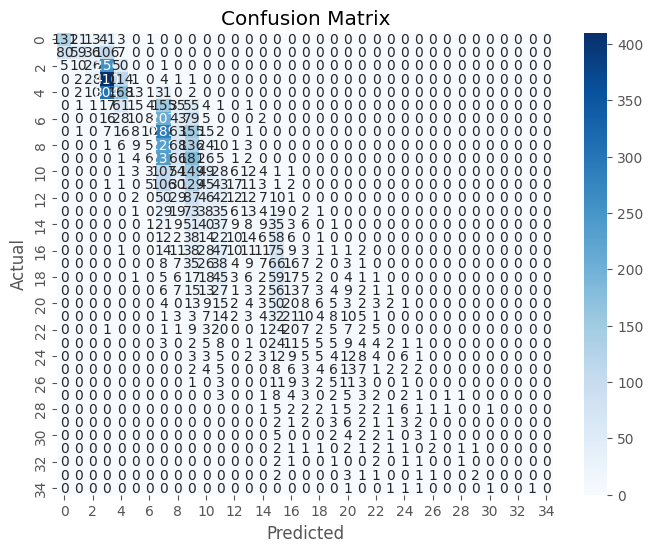

In [ ]:
# 4. Evaluation
print("--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/tmp/ipykernel_67783/2347287647.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(20), x='importance', y='feature', palette='viridis')


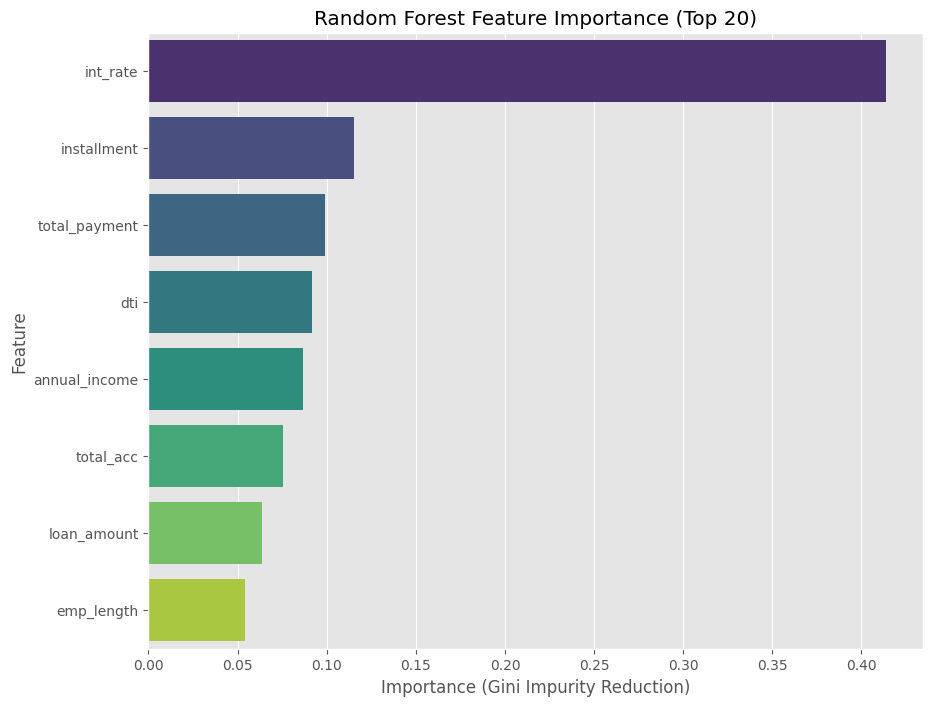

In [ ]:
# 1. Get the feature names from the One-Hot Encoder
# This looks at the 'cat' step of the preprocessor inside the pipeline
if dropping == True:
    ohe_feature_names = []
else:
    ohe_feature_names = rf_pipeline.named_steps['preprocessor']\
                        .transformers_[0][1]\
                        .get_feature_names_out(categorical_features)

# 2. Combine with the numeric feature names (which didn't change)
all_feature_names = list(ohe_feature_names) + numeric_features

# 3. Grab the importance values from the classifier
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# 4. Create a DataFrame for easy plotting
feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 5. Plot the top 20
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Random Forest Feature Importance (Top 20)')
plt.xlabel('Importance (Gini Impurity Reduction)')
plt.ylabel('Feature')
plt.show()

In [ ]:
feat_imp_df

,feature,importance
4,int_rate,0.414034
3,installment,0.115155
7,total_payment,0.098791
2,dti,0.092012
1,annual_income,0.086528
6,total_acc,0.075762
5,loan_amount,0.063799
0,emp_length,0.053920
